In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
print(os.path.exists('/content/drive/MyDrive/deepfake_project/phase2_model.pth'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
False


In [ ]:
import os
print(os.path.exists('/content/data/real_vs_fake/real-vs-fake'))

True


In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = "KGAT_ddcc75be608a47fc14720488f906d033"  # paste your NEW regenerated token, not the leaked one

In [ ]:
!pip install -q kaggle
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces -p /content/data

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
140k-real-and-fake-faces.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:

!unzip -q /content/data/140k-real-and-fake-faces.zip -d /content/data

replace /content/data/real_vs_fake/real-vs-fake/test/fake/00276TOPP4.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os
for item in os.listdir('/content/data'):
    print(item)

valid.csv
140k-real-and-fake-faces.zip
train.csv
real_vs_fake
test.csv


In [ ]:
base_check = '/content/data/real_vs_fake'  # adjust based on above output
for item in os.listdir(base_check):
    print(item)

real-vs-fake


In [ ]:
base = '/content/data/real_vs_fake/real-vs-fake'

# quick verification, same check as Kaggle
for split in ['train', 'valid', 'test']:
    for label in ['real', 'fake']:
        path = os.path.join(base, split, label)
        if os.path.exists(path):
            print(f"{split}/{label}: {len(os.listdir(path))} images")
        else:
            print(f"{split}/{label}: PATH NOT FOUND — {path}")

train/real: 50000 images
train/fake: 50000 images
valid/real: 10000 images
valid/fake: 10000 images
test/real: 10000 images
test/fake: 10000 images


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")  # must say cuda — if not, GPU isn't attached yet

Using device: cuda


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
base = '/content/data/real_vs_fake/real-vs-fake'

train_dataset = ImageFolder(root=os.path.join(base, 'train'), transform=train_transform)
valid_dataset = ImageFolder(root=os.path.join(base, 'valid'), transform=val_transform)
test_dataset = ImageFolder(root=os.path.join(base, 'test'), transform=val_transform)

print(train_dataset.classes)  # confirm still ['fake', 'real']
print(len(train_dataset), len(valid_dataset), len(test_dataset))

['fake', 'real']
100000 20000 20000


In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}, Valid batches: {len(valid_loader)}, Test batches: {len(test_loader)}")

Train batches: 3125, Valid batches: 625, Test batches: 625


In [ ]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)
print(labels[:10])

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor([1, 0, 1, 0, 0, 1, 1, 1, 0, 1])


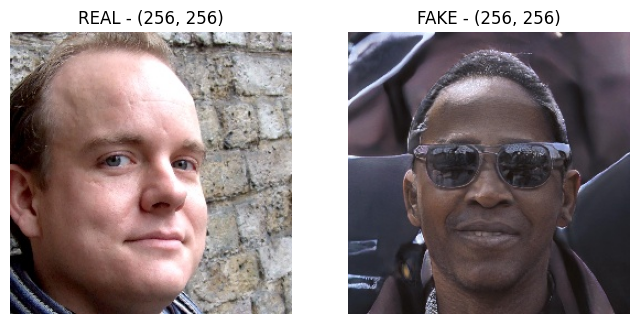

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Using the previously defined base path for Colab
base = '/content/data/real_vs_fake/real-vs-fake'

real_dir = os.path.join(base, 'train', 'real')
fake_dir = os.path.join(base, 'train', 'fake')

real_sample = os.listdir(real_dir)[0]
fake_sample = os.listdir(fake_dir)[0]

real_img = Image.open(os.path.join(real_dir, real_sample))
fake_img = Image.open(os.path.join(fake_dir, fake_sample))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(real_img)
axes[0].set_title(f"REAL - {real_img.size}")
axes[0].axis('off')

axes[1].imshow(fake_img)
axes[1].set_title(f"FAKE - {fake_img.size}")
axes[1].axis('off')

plt.show()

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32  # good default for 224x224 images on a T4/P100 GPU — bump up if you don't hit memory errors

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,       # shuffle training data every epoch — prevents the model from learning order-dependent patterns
    num_workers=2,      # parallel data loading — Kaggle notebooks typically give you 2-4 CPU cores
    pin_memory=True      # speeds up CPU->GPU transfer, worth it since you're on GPU
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,       # no need to shuffle validation — order doesn't matter, and you want reproducibility
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,       # same reasoning as valid — never shuffle test either
    num_workers=2,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}, Valid batches: {len(valid_loader)}, Test batches: {len(test_loader)}")

Train batches: 3125, Valid batches: 625, Test batches: 625


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")  # should print cuda — if it prints cpu, your GPU accelerator isn't turned on

# Load pretrained ResNet50 (trained on ImageNet)
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

# Unfreeze the last ResNet block (layer4) + the head — keep earlier layers frozen
for name, param in model.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)  # THIS is the line that was missing/skipped
# New optimizer — must include layer4 + fc params now, and use a LOWER learning rate
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

print(model.fc)  # confirm this is still your trained head, Linear(in_features=2048, out_features=1

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 139MB/s]


Linear(in_features=2048, out_features=1, bias=True)


In [ ]:
criterion = nn.BCEWithLogitsLoss()  # combines sigmoid + binary cross-entropy in one stable operation — don't apply sigmoid separately before this

# optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)  # only optimizing the head's params, since backbone is fSrozen

In [ ]:
print(f"Device variable: {device}")
print(f"Model is on: {next(model.parameters()).device}")

model = model.to(device)

print(f"Model is now on: {next(model.parameters()).device}")

Device variable: cuda
Model is on: cpu
Model is now on: cuda:0


In [ ]:
import time

EPOCHS = 5

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


for epoch in range(EPOCHS):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, valid_loader, criterion, device)
    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
          f"Time: {elapsed:.1f}s")

Epoch 1/5 | Train Loss: 0.1877, Train Acc: 0.9256 | Val Loss: 0.0919, Val Acc: 0.9677 | Time: 631.6s
Epoch 2/5 | Train Loss: 0.0778, Train Acc: 0.9714 | Val Loss: 0.0543, Val Acc: 0.9806 | Time: 629.4s
Epoch 3/5 | Train Loss: 0.0453, Train Acc: 0.9840 | Val Loss: 0.0402, Val Acc: 0.9857 | Time: 629.9s
Epoch 4/5 | Train Loss: 0.0282, Train Acc: 0.9906 | Val Loss: 0.0345, Val Acc: 0.9876 | Time: 625.4s
Epoch 5/5 | Train Loss: 0.0205, Train Acc: 0.9933 | Val Loss: 0.0290, Val Acc: 0.9899 | Time: 627.1s


In [ ]:
import os
print(os.path.exists('/content/drive/MyDrive/deepfake_project/phase1_model.pth'))

False


In [ ]:
import os
os.makedirs('/content/drive/MyDrive/deepfake_project', exist_ok=True)

torch.save(model.state_dict(), '/content/drive/MyDrive/deepfake_project/phase2_model.pth')
print("✅ Saved")

print(os.path.exists('/content/drive/MyDrive/deepfake_project/phase2_model.pth'))

✅ Saved
True


In [ ]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

test_loss, test_acc = validate_one_epoch(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Test Loss: 0.0281, Test Acc: 0.9902


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Hook to capture the gradients and activations from layer4 (last conv block)
activations = {}
gradients = {}

def forward_hook(module, input, output):
    activations['value'] = output.detach()

def backward_hook(module, grad_input, grad_output):
    gradients['value'] = grad_output[0].detach()

# Register hooks on layer4 (the last convolutional block — standard Grad-CAM target)
target_layer = model.layer4[-1]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

def generate_gradcam(model, image_tensor, device):
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)  # add batch dim
    image_tensor.requires_grad = False

    output = model(image_tensor)  # forward pass, raw logit
    pred_prob = torch.sigmoid(output).item()
    pred_class = 1 if pred_prob > 0.5 else 0  # 1=real, 0=fake per your label mapping

    model.zero_grad()
    output.backward()  # backprop from the single output neuron — binary case, no need to select a class index

    grads = gradients['value'][0]      # shape [512, 7, 7] for layer4 output (channels, H, W)
    acts = activations['value'][0]     # same shape

    weights = grads.mean(dim=(1, 2))   # global average pool the gradients -> importance weight per channel
    cam = torch.zeros(acts.shape[1:], dtype=torch.float32).to(device)

    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = torch.relu(cam)              # only positive influence matters
    cam = cam.cpu().numpy()
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)  # normalize to [0,1]

    return cam, pred_prob, pred_class

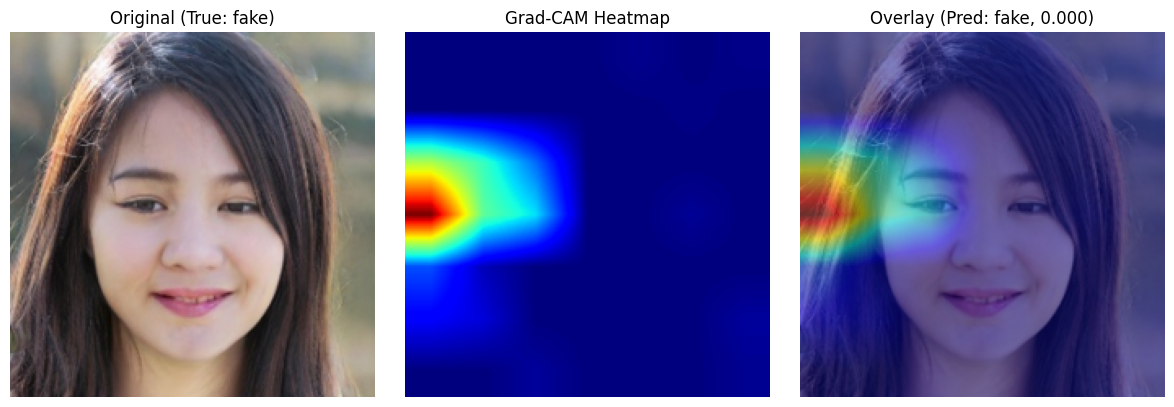

In [ ]:
# Grab one test image + its true label
image_tensor, true_label = test_dataset[0]  # change index to try different samples

cam, pred_prob, pred_class = generate_gradcam(model, image_tensor, device)

# Unnormalize the image for display
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_display = image_tensor.permute(1, 2, 0).numpy()
img_display = std * img_display + mean
img_display = np.clip(img_display, 0, 1)

heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
overlay = 0.5 * img_display + 0.5 * heatmap

label_names = ['fake', 'real']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_display); axes[0].set_title(f"Original (True: {label_names[true_label]})"); axes[0].axis('off')
axes[1].imshow(cam, cmap='jet'); axes[1].set_title("Grad-CAM Heatmap"); axes[1].axis('off')
axes[2].imshow(overlay); axes[2].set_title(f"Overlay (Pred: {label_names[pred_class]}, {pred_prob:.3f})"); axes[2].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def show_gradcam(model, dataset, index, device, label_names=['fake', 'real']):
    image_tensor, true_label = dataset[index]
    cam, pred_prob, pred_class = generate_gradcam(model, image_tensor, device)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = image_tensor.permute(1, 2, 0).numpy()
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1)

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.5 * img_display + 0.5 * heatmap

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_display)
    axes[0].set_title(f"Original (True: {label_names[true_label]})")
    axes[0].axis('off')

    axes[1].imshow(cam, cmap='jet')
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title(f"Overlay (Pred: {label_names[pred_class]}, {pred_prob:.3f})")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

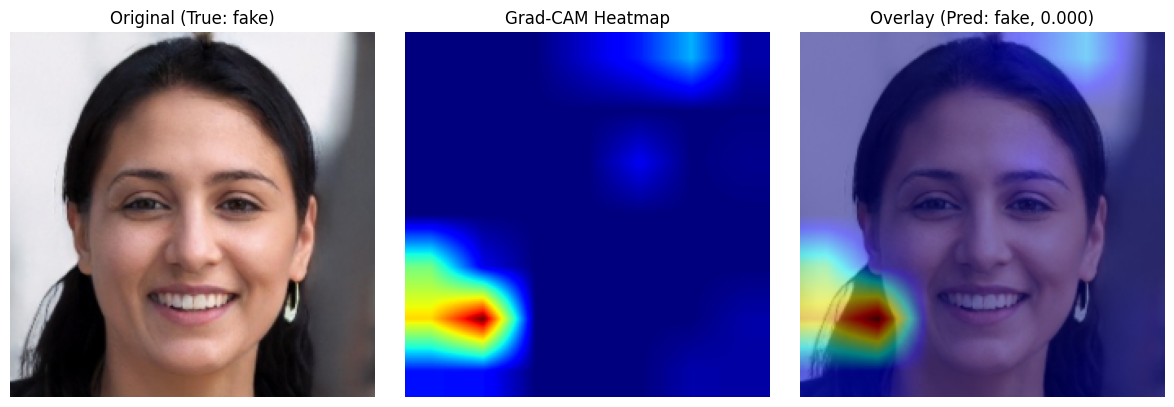

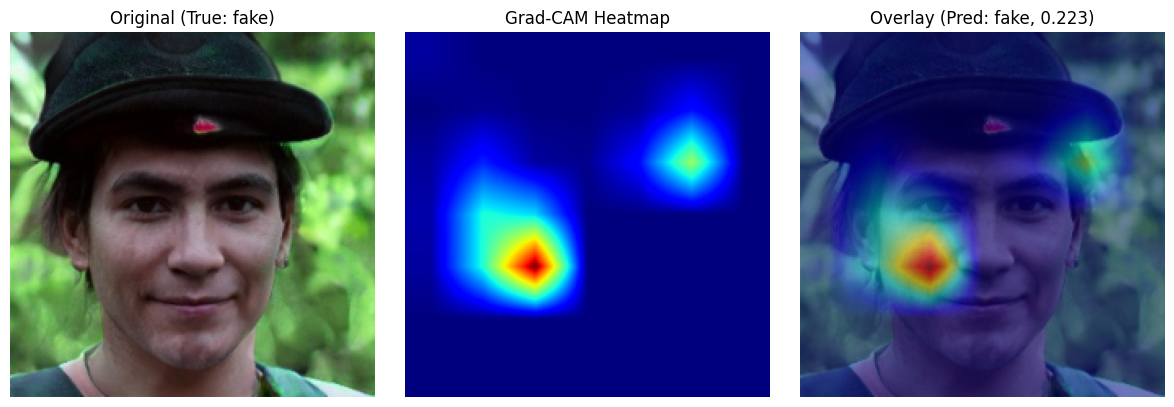

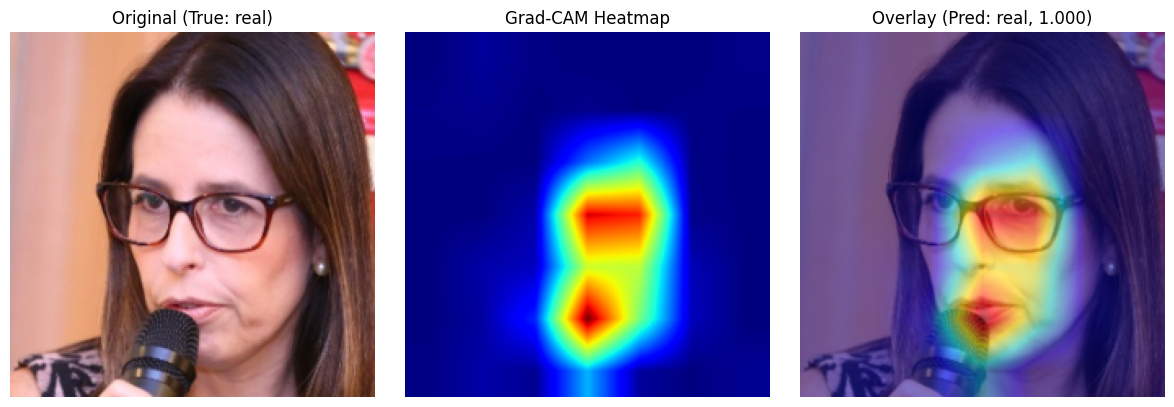

In [ ]:
show_gradcam(model, test_dataset, index=10, device=device)
show_gradcam(model, test_dataset, index=250, device=device)
show_gradcam(model, test_dataset, index=15000, device=device)  # a 'real' sample, since fakes are likely first N indices

In [2]:
from google.colab import userdata
token = userdata.get('GITHUB')  # matches the actual secret name you saved

!git clone https://{token}@github.com/aryansh0910/deepfake-detection.git

Cloning into 'deepfake-detection'...


In [4]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [3]:
import os
for item in os.listdir('/content/drive/MyDrive/deepfake_project'):
    print(item)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/deepfake_project'